収録されているstep: [47921, 62059]
step=47921: gamma=1.0, epsilon=2.0e-07, accept_full_avg=0.515
step=62059: gamma=1.0, epsilon=2.0e-07, accept_full_avg=0.515


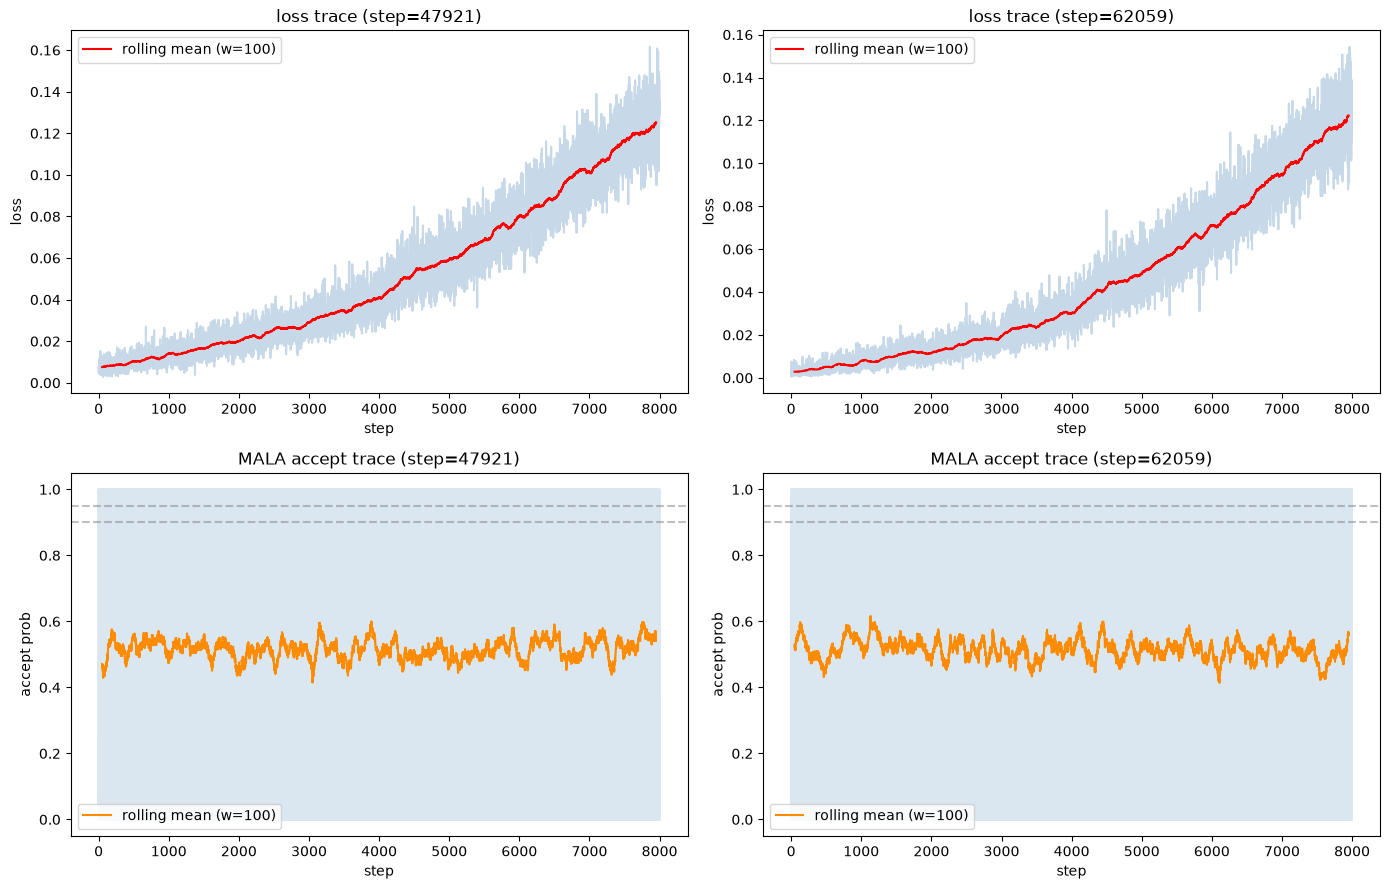

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/nakano/server/calibration_results_vision_resnet_setting")
NET = "convnext-atto"

records = {}
for f in ROOT.glob(f"calib_{NET}_step*.json"):
    d = json.load(open(f))
    for r in d["records"]:
        records[r["step"]] = r

print("収録されているstep:", sorted(records.keys()))
for step, r in sorted(records.items()):
    print(f"step={step}: gamma={r['gamma']}, epsilon={r['epsilon']:.1e}, "
          f"accept_full_avg={r['mean_accept_prob_full']:.3f}")
def rolling_mean(x, window=100):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode='valid')

steps_sorted = sorted(records.keys())
n = len(steps_sorted)

fig, axes = plt.subplots(2, n, figsize=(7*n, 9))
if n == 1:
    axes = axes.reshape(2, 1)

for i, step in enumerate(steps_sorted):
    r = records[step]
    trace = np.array(r["loss_trace"])
    rm = rolling_mean(trace, window=100)
    accept_trace = np.array(r["mala_accept_trace"])
    accept_rm = rolling_mean(accept_trace, window=100)

    axes[0, i].plot(trace, alpha=0.3, color="steelblue")
    axes[0, i].plot(np.arange(len(rm)) + 50, rm, color="red", label="rolling mean (w=100)")
    axes[0, i].set_title(f"loss trace (step={step})")
    axes[0, i].set_xlabel("step")
    axes[0, i].set_ylabel("loss")
    axes[0, i].legend()

    axes[1, i].plot(accept_trace, alpha=0.2, color="steelblue")
    axes[1, i].plot(np.arange(len(accept_rm)) + 50, accept_rm, color="darkorange", label="rolling mean (w=100)")
    axes[1, i].set_title(f"MALA accept trace (step={step})")
    axes[1, i].set_xlabel("step")
    axes[1, i].set_ylabel("accept prob")
    axes[1, i].set_ylim(-0.05, 1.05)
    axes[1, i].axhline(0.9, color="gray", linestyle="--", alpha=0.5)
    axes[1, i].axhline(0.95, color="gray", linestyle="--", alpha=0.5)
    axes[1, i].legend()

plt.tight_layout()
plt.show()

In [4]:
def compute_llc_with_burnin_step(loss_trace, nbeta, burnin_step):
    trace = np.array(loss_trace)
    post_burnin = trace[burnin_step:]
    init_loss = trace[0]
    avg_loss = post_burnin.mean()
    llc = nbeta * (avg_loss - init_loss)
    return llc, avg_loss, len(post_burnin)

for step in steps_sorted:
    r = records[step]
    print(f"\n=== step={step} (nbeta={r['nbeta']:.1f}, epsilon={r['epsilon']:.1e}, gamma={r['gamma']}) ===")
    total = len(r["loss_trace"])
    for frac in [0.3, 0.5, 0.7, 0.8, 0.9]:
        b = int(total * frac)
        llc, avg_loss, np_ = compute_llc_with_burnin_step(r["loss_trace"], r["nbeta"], b)
        print(f"  burnin={frac*100:.0f}% (step={b:5d}): llc={llc:9.3f}  avg_loss={avg_loss:.5f}  n_post={np_}")


=== step=47921 (nbeta=4621.2, epsilon=2.0e-07, gamma=1.0) ===
  burnin=30% (step= 2400): llc=  277.949  avg_loss=0.06736  n_post=5600
  burnin=50% (step= 4000): llc=  343.732  avg_loss=0.08160  n_post=4000
  burnin=70% (step= 5600): llc=  421.336  avg_loss=0.09839  n_post=2400
  burnin=80% (step= 6400): llc=  464.890  avg_loss=0.10782  n_post=1600
  burnin=90% (step= 7200): llc=  509.156  avg_loss=0.11739  n_post=800

=== step=62059 (nbeta=4621.2, epsilon=2.0e-07, gamma=1.0) ===
  burnin=30% (step= 2400): llc=  263.712  avg_loss=0.05872  n_post=5600
  burnin=50% (step= 4000): llc=  330.822  avg_loss=0.07324  n_post=4000
  burnin=70% (step= 5600): llc=  413.372  avg_loss=0.09110  n_post=2400
  burnin=80% (step= 6400): llc=  461.561  avg_loss=0.10153  n_post=1600
  burnin=90% (step= 7200): llc=  512.278  avg_loss=0.11250  n_post=800
